In [1]:
from google.colab import files
uploaded = files.upload()


Saving faang_stock_prices.csv to faang_stock_prices.csv


In [10]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [11]:
import pandas as pd
df = pd.read_csv('faang_stock_prices.csv')
print(df.head())

         Date Ticker        Open        High         Low       Close  \
0  2016-02-23   AAPL   21.853144   21.875812   21.433763   21.465500   
1  2016-02-23   AMZN   27.777500   27.845501   27.266500   27.646999   
2  2016-02-23  GOOGL   36.032746   36.270944   35.515157   35.595547   
3  2016-02-23   META  106.108789  106.724491  104.390794  104.728432   
4  2016-02-23   MSFT   46.158514   46.184970   44.959133   45.135513   

      Volume       SMA_7      SMA_21      EMA_12      EMA_26     RSI_14  \
0  127770400   21.782546   21.682435   21.720115   21.827292  52.112369   
1   81016000   26.675857   27.140333   26.765295   27.363824  50.230010   
2   41332000   35.747473   36.132564   35.810892   36.019909  28.846871   
3   25319300  103.488525  103.976073  103.607174  102.390311  34.031434   
4   28895300   45.542440   45.303900   45.301104   45.262960  42.877882   

       MACD  MACD_Signal  Bollinger_Upper  Bollinger_Lower  Daily_Return  \
0 -0.107176    -0.149939        22.40153

In [12]:
df = df[df['Ticker'] == 'AAPL']   # Apple

df = df[['Date', 'Close']]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [13]:
df = df[['Close']]

In [14]:
print(df.head())

        Close
0   21.465500
6   21.785145
12  21.934757
18  21.968756
24  21.918888


In [16]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

In [17]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

In [18]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

In [19]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 0.0085
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 3.1470e-04
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 3.1285e-04
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 2.9001e-04
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 2.7653e-04
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 3.1027e-04
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 2.6471e-04
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 2.6208e-04
Epoch 9/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 2.6743e-04
Epoch 10/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 2.6113e-04


In [21]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Convert back to original scale
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


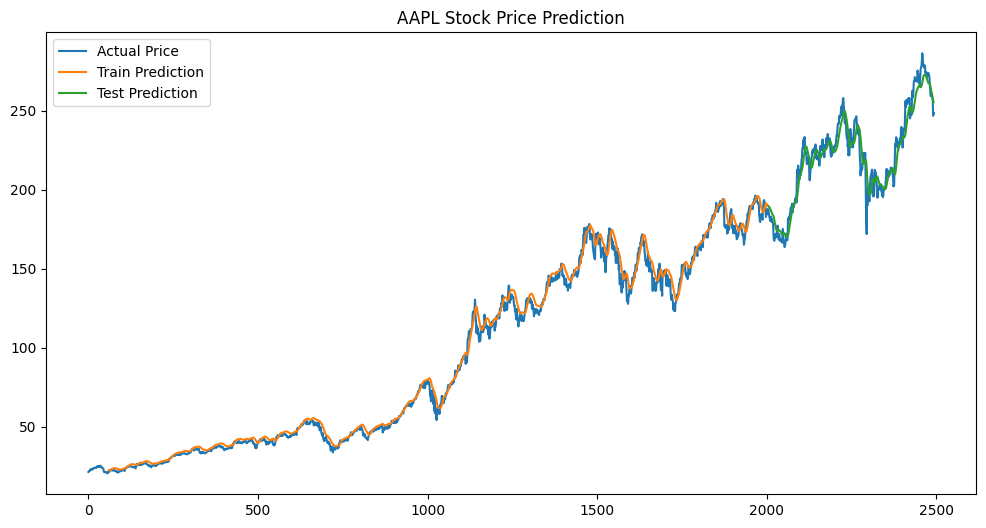

In [23]:
plt.figure(figsize=(12,6))

# Actual data
plt.plot(scaler.inverse_transform(scaled_data), label='Actual Price')

# Train predictions
train_plot = np.empty_like(scaled_data)
train_plot[:] = np.nan
train_plot[time_step:len(train_pred)+time_step] = train_pred

# Test predictions
test_plot = np.empty_like(scaled_data)
test_plot[:] = np.nan
test_plot[train_size + time_step : len(y) + time_step] = test_pred

plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')

company = 'AAPL'
plt.title(f"{company} Stock Price Prediction")
plt.legend()
plt.show()

In [24]:
last_60_days = scaled_data[-time_step:]
last_60_days = last_60_days.reshape(1, time_step, 1)

next_day = model.predict(last_60_days)
next_price = scaler.inverse_transform(next_day)

print(f"Next Day Predicted Price for {company}:", next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Next Day Predicted Price for AAPL: 252.16684


In [25]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(y_test, test_pred))
print("RMSE:", rmse)

RMSE: 221.22402875444794


In [26]:
# RSI
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# MACD
def compute_macd(data):
    ema12 = data.ewm(span=12, adjust=False).mean()
    ema26 = data.ewm(span=26, adjust=False).mean()

    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()

    return macd, signal

In [27]:
df['RSI'] = compute_rsi(df['Close'])
df['MACD'], df['Signal'] = compute_macd(df['Close'])

# Drop NaN values
df = df.dropna()

print(df.head())

         Close        RSI      MACD    Signal
78   23.181561  81.620874  0.427047  0.345036
84   23.240498  82.011583  0.436616  0.363352
90   23.707489  82.919368  0.476390  0.385960
96   24.022596  83.835578  0.527260  0.414220
102  23.984055  82.611965  0.558033  0.442982


In [28]:
features = df[['Close', 'RSI', 'MACD', 'Signal']]

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(features)

In [29]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step, 0])  # Predict Close price
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

In [30]:
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

In [31]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

In [32]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(time_step, 4)))
model.add(LSTM(64))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.0097
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 2.3071e-04
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 2.1588e-04
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 2.3956e-04
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 2.2683e-04
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 2.3505e-04
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 2.1111e-04
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 2.2423e-04
Epoch 9/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 1.8352e-04
Epoch 10/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 2.0590e-04


In [34]:
pred = model.predict(X_test)

# Inverse transform only Close column
close_scaler = MinMaxScaler()
close_scaler.fit_transform(df[['Close']])

pred = close_scaler.inverse_transform(pred)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [35]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.8 MB/s eta 0:00:00


In [38]:
# Load dataset
df = pd.read_csv('faang_stock_prices.csv')

# Filter one company (VERY IMPORTANT)
df = df[df['Ticker'] == 'AAPL']

# Convert date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Set index for mplfinance
df.set_index('Date', inplace=True)

In [39]:
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['Close'])

In [40]:
def compute_macd(data):
    ema12 = data.ewm(span=12, adjust=False).mean()
    ema26 = data.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    return macd, signal

df['MACD'], df['Signal'] = compute_macd(df['Close'])

In [41]:
df = df.dropna()

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


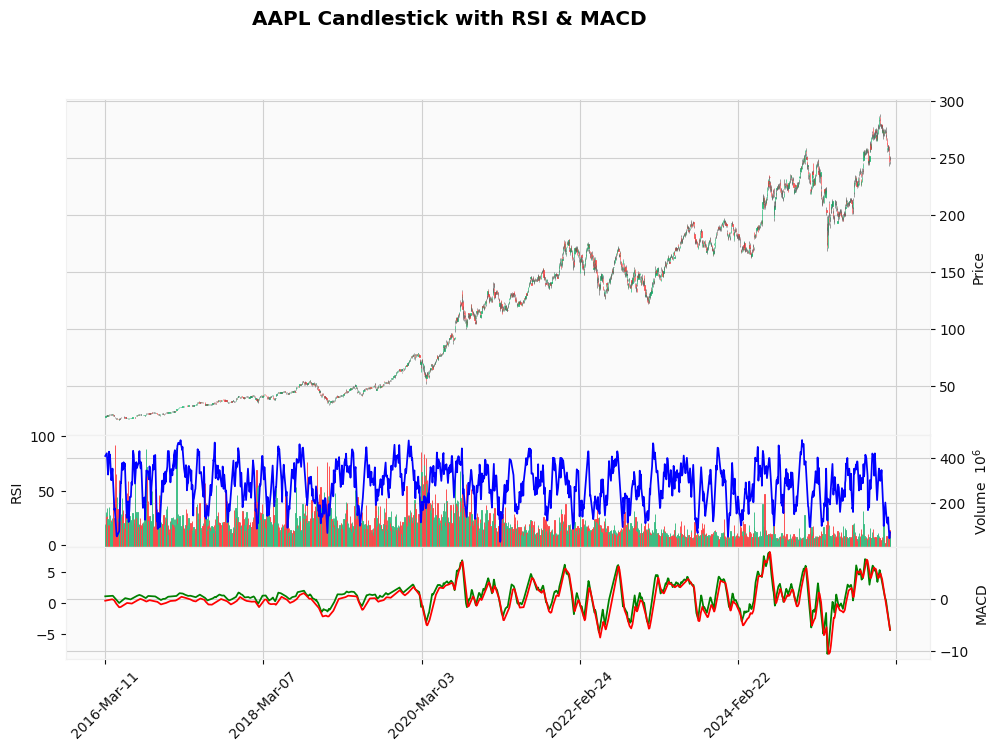

In [43]:
import mplfinance as mpf

# RSI plot
rsi_plot = mpf.make_addplot(df['RSI'], panel=1, color='blue', ylabel='RSI')

# MACD plots
macd_plot = mpf.make_addplot(df['MACD'], panel=2, color='green', ylabel='MACD')
signal_plot = mpf.make_addplot(df['Signal'], panel=2, color='red')

# Combine plots
add_plots = [rsi_plot, macd_plot, signal_plot]

# Candlestick chart
mpf.plot(
    df,
    type='candle',
    style='yahoo',
    title='AAPL Candlestick with RSI & MACD',
    ylabel='Price',
    volume=True,
    addplot=add_plots,
    panel_ratios=(3,1,1),
    figsize=(12,8)
)